# Signal correlation — how much leading indicators overlap, per position
_Rank-correlation (Spearman) among the live leading indicators within each position — which carry overlapping information and which are independent. Exact composites (`xgi`, `ict_index`) are dropped in favour of their parts to avoid trivial self-correlation. DGW excluded._

**Sections:** (a) correlation matrix per position · (b) most-redundant pairs

---

## Setup
> Whole season, `minutes > 0`, **DGW excluded**; the signal universe is the leading indicators with exact composites dropped, restricted per position to the `leading_alive` set from the relevance kernel.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dal.pipeline import load as load_mart, run as run_pipeline
from dal.exceptions import MartNotBuiltError, MartSchemaError
from research.kernels.descriptive.relevance import (
    compute_relevance, leading_indicator_signals, leading_alive_signals, POSITIONS,
)

POSITIONS = list(POSITIONS)

try:
    _r = load_mart()
except (MartNotBuiltError, MartSchemaError) as _e:
    print(f"Rebuilding mart ({type(_e).__name__})...")
    run_pipeline(force=True)
    _r = load_mart()

mart = _r.mart
df = mart[mart["gw"].between(1, _r.data_cutoff_gw)].copy()
df = df[df["minutes"].notna() & (df["minutes"] > 0)].copy()
df = df[df["is_dgw"] == False].copy()

leading = sorted(leading_indicator_signals(drop_exact_composites=True))
alive_by_pos = {}
for p in POSITIONS:
    rel = compute_relevance(df[df["position"] == p], signals=leading, group_cols=())
    alive_by_pos[p] = leading_alive_signals(rel)

print(f"Study range: GW 1 - {_r.data_cutoff_gw} · minutes > 0 · DGW excluded · n = {len(df):,}")
print(f"Leading universe (exact composites dropped): {leading}")
for p in POSITIONS:
    print(f"  {p}: {len(alive_by_pos[p])} alive -> {alive_by_pos[p]}")

Study range: GW 1 - 38 · minutes > 0 · DGW excluded · n = 11,190
Leading universe (exact composites dropped): ['clearances_blocks_interceptions', 'creativity', 'defensive_contribution', 'influence', 'recoveries', 'tackles', 'threat', 'xa', 'xg']
  GK: 3 alive -> ['clearances_blocks_interceptions', 'influence', 'recoveries']
  DEF: 9 alive -> ['clearances_blocks_interceptions', 'creativity', 'defensive_contribution', 'influence', 'recoveries', 'tackles', 'threat', 'xa', 'xg']
  MID: 9 alive -> ['clearances_blocks_interceptions', 'creativity', 'defensive_contribution', 'influence', 'recoveries', 'tackles', 'threat', 'xa', 'xg']
  FWD: 9 alive -> ['clearances_blocks_interceptions', 'creativity', 'defensive_contribution', 'influence', 'recoveries', 'tackles', 'threat', 'xa', 'xg']


## (a) Correlation matrix per position
> Within a position, which leading indicators move together?

Spearman rho among the `leading_alive` signals for each position. Goalkeepers have only a few live signals; the outfield matrices separate the attacking block (xg / xa / threat / creativity / influence) from the defensive block (CBI / tackles / recoveries / defensive_contribution).

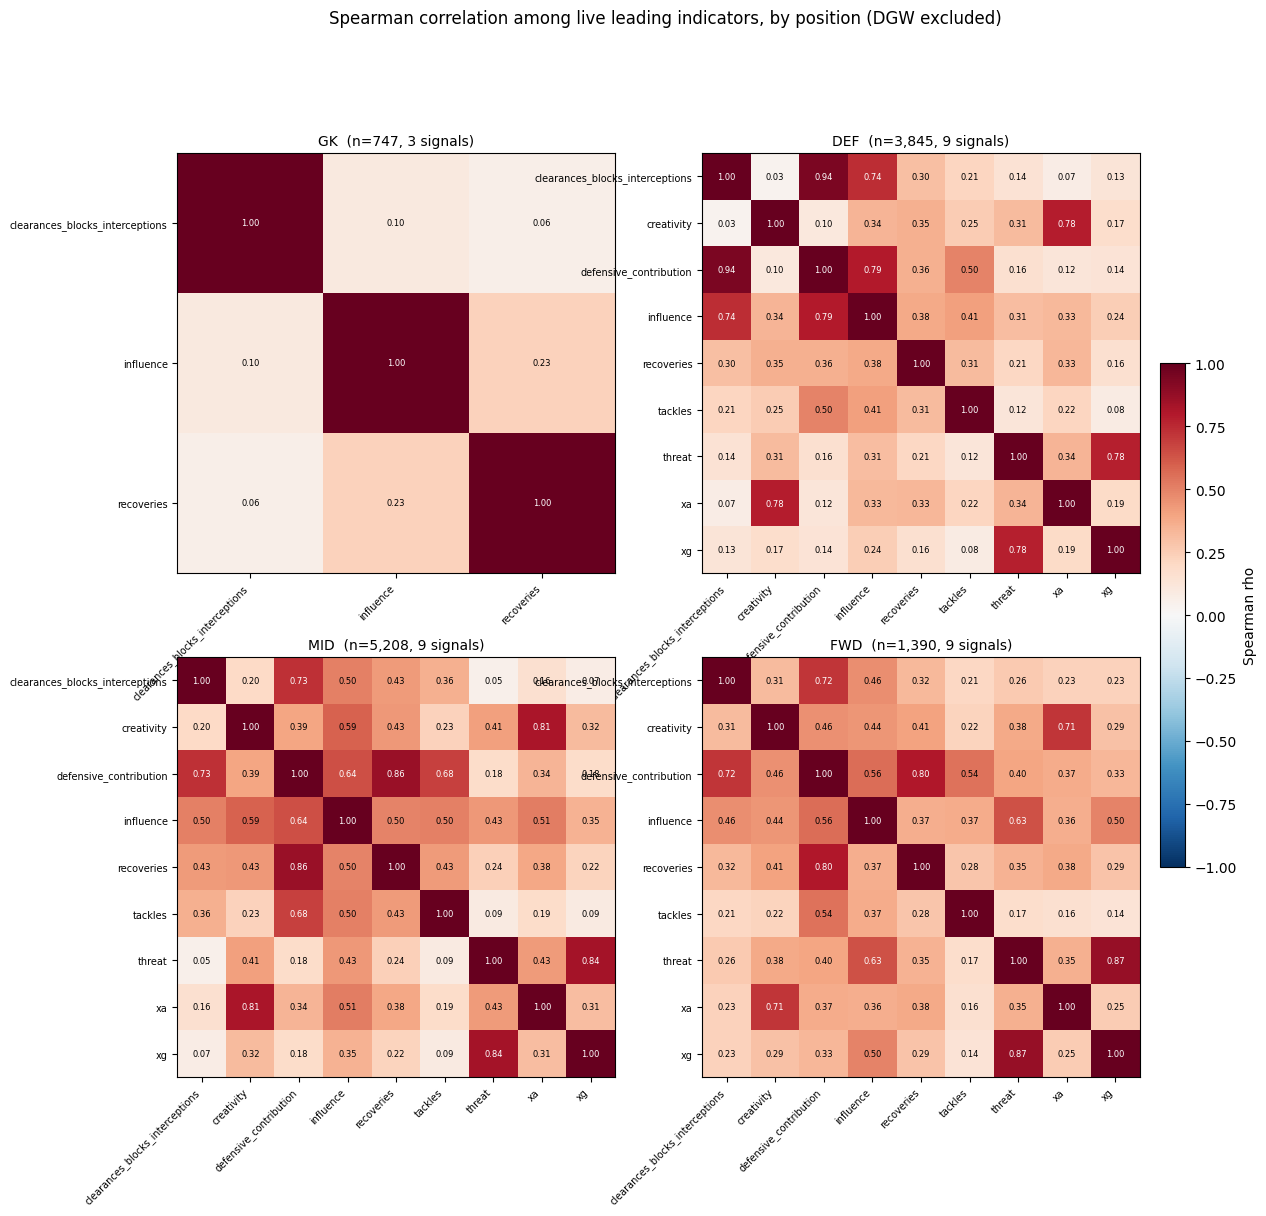

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(13, 12))
for ax, p in zip(axes.ravel(), POSITIONS):
    cols = alive_by_pos[p]
    n = int((df["position"] == p).sum())
    if len(cols) < 2:
        ax.text(0.5, 0.5, f"{p}: < 2 live signals", ha="center", va="center")
        ax.set_axis_off()
        continue
    C = df.loc[df["position"] == p, cols].corr(method="spearman")
    im = ax.imshow(C.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
    ax.set_xticks(range(len(cols))); ax.set_xticklabels(cols, rotation=45, ha="right", fontsize=7)
    ax.set_yticks(range(len(cols))); ax.set_yticklabels(cols, fontsize=7)
    for i in range(len(cols)):
        for j in range(len(cols)):
            v = C.values[i, j]
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=6,
                    color="white" if abs(v) > 0.6 else "black")
    ax.set_title(f"{p}  (n={n:,}, {len(cols)} signals)", fontsize=10)
fig.suptitle("Spearman correlation among live leading indicators, by position (DGW excluded)", y=1.0)
fig.colorbar(im, ax=axes, label="Spearman rho", fraction=0.025, pad=0.02)
plt.show()

## (b) Most-redundant pairs
> Which signal pairs are near-duplicates?

The highest-|rho| leading-indicator pairs across positions — pairs near 1 carry essentially the same information (one could proxy the other), pairs near 0 are independent.

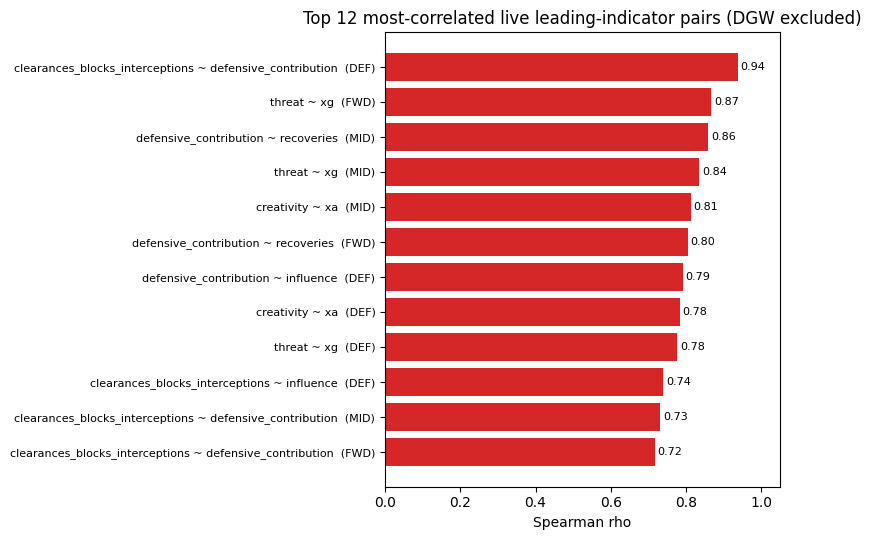

In [3]:
pairs = []
for p in POSITIONS:
    cols = alive_by_pos[p]
    if len(cols) < 2:
        continue
    C = df.loc[df["position"] == p, cols].corr(method="spearman")
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            rho = C.iloc[i, j]
            pairs.append((f"{cols[i]} ~ {cols[j]}  ({p})", rho))
pairs.sort(key=lambda t: -abs(t[1]))
top = pairs[:12][::-1]
labels = [t[0] for t in top]
vals = [t[1] for t in top]

fig, ax = plt.subplots(figsize=(8, 5.5))
colors = ["#d62728" if v >= 0 else "#1f77b4" for v in vals]
bars = ax.barh(range(len(top)), vals, color=colors)
ax.bar_label(bars, fmt="%.2f", fontsize=8, padding=2)
ax.set_yticks(range(len(top))); ax.set_yticklabels(labels, fontsize=8)
ax.set_xlim(0, 1.05)
ax.set_xlabel("Spearman rho")
ax.set_title("Top 12 most-correlated live leading-indicator pairs (DGW excluded)")
plt.tight_layout()
plt.show()